# E-commerce A/B Test — Statistical Analysis

## The question

The cleaned data shows:
- Control conversion: 12.039%
- Treatment conversion: 11.881%
- Absolute difference: -0.158 percentage points (treatment performs slightly worse)

But with ~145K users per group, some difference between the two numbers is expected purely from random sampling variability. Is this gap real signal, or just noise?

## The test we'll use

For comparing conversion rates between two groups, the standard test is a **two-proportion z-test**. It answers: "If the two groups actually had the same true conversion rate, what is the probability of seeing a difference at least this large by random chance?"

That probability is the **p-value**. By convention:
- p < 0.05 → "statistically significant" → the difference is unlikely to be chance → we reject the null hypothesis
- p ≥ 0.05 → "not statistically significant" → the observed difference is consistent with chance

## The hypotheses

- **Null hypothesis (H₀):** The new page has the same true conversion rate as the old page. Any observed difference is random noise.
- **Alternative hypothesis (H₁):** The new page has a different true conversion rate than the old page.

We are testing a **two-sided alternative** — we're open to the new page being either better or worse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

pd.set_option("display.float_format", "{:,.4f}".format)

df = pd.read_csv("/Users/edi/Documents/ab-test-analysis/data/ab_data_clean.csv")
print(f"Loaded {len(df):,} cleaned rows")

Loaded 290,584 cleaned rows


In [2]:
# Compute the counts we need
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

n_control = len(control)
n_treatment = len(treatment)
conv_control = control["converted"].sum()
conv_treatment = treatment["converted"].sum()

rate_control = conv_control / n_control
rate_treatment = conv_treatment / n_treatment

print(f"Control:   {conv_control:,} conversions / {n_control:,} users = {rate_control*100:.3f}%")
print(f"Treatment: {conv_treatment:,} conversions / {n_treatment:,} users = {rate_treatment*100:.3f}%")
print(f"\nAbsolute difference: {(rate_treatment - rate_control)*100:+.3f} percentage points")
print(f"Relative difference: {(rate_treatment - rate_control)/rate_control*100:+.2f}%")

Control:   17,489 conversions / 145,274 users = 12.039%
Treatment: 17,264 conversions / 145,310 users = 11.881%

Absolute difference: -0.158 percentage points
Relative difference: -1.31%


## Running the two-proportion z-test

Checking whether the observed difference in conversion rates between treatment and control is larger than expected by random chance.

In [4]:
# Two-proportion z-test
successes = np.array([conv_control, conv_treatment])
nobs = np.array([n_control, n_treatment])

z_stat, p_value = proportions_ztest(successes, nobs, alternative="two-sided")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 1.3109
P-value: 0.1899


In [6]:
print(f"\nInterpretation:")
print(f"  p ≥ 0.05 → NOT statistically significant")
print(f"  The observed difference is consistent with random chance.")
print(f"  Fail to reject the null hypothesis.")


Interpretation:
  p ≥ 0.05 → NOT statistically significant
  The observed difference is consistent with random chance.
  Fail to reject the null hypothesis.


## Confidence intervals

A p-value tells us whether the difference is "real." A **confidence interval** gives us a range of plausible values for each group's true conversion rate. If the two intervals overlap substantially, that's a visual way of seeing why the groups aren't statistically distinguishable.

In [7]:
# 95% confidence intervals for each group
ci_control = proportion_confint(conv_control, n_control, alpha=0.05, method="normal")
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method="normal")

print("95% Confidence Intervals:")
print(f"  Control:   [{ci_control[0]*100:.3f}%, {ci_control[1]*100:.3f}%]")
print(f"  Treatment: [{ci_treatment[0]*100:.3f}%, {ci_treatment[1]*100:.3f}%]")

95% Confidence Intervals:
  Control:   [11.871%, 12.206%]
  Treatment: [11.714%, 12.047%]


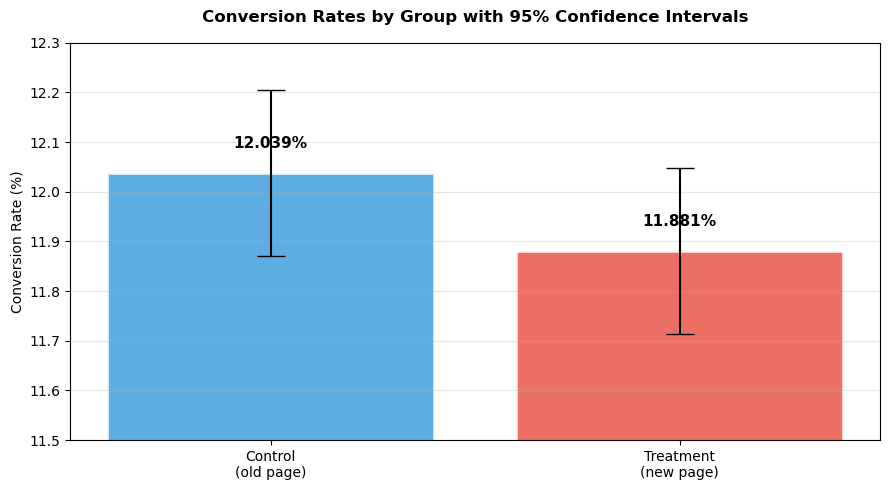

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

groups = ["Control\n(old page)", "Treatment\n(new page)"]
rates = [rate_control * 100, rate_treatment * 100]
errors = [
    [(rate_control - ci_control[0]) * 100, (rate_treatment - ci_treatment[0]) * 100],
    [(ci_control[1] - rate_control) * 100, (ci_treatment[1] - rate_treatment) * 100],
]

bars = ax.bar(groups, rates, color=["#3498db", "#e74c3c"], alpha=0.8, 
              yerr=errors, capsize=10, edgecolor="white", linewidth=2)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.05, 
            f"{rate:.3f}%", ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rates by Group with 95% Confidence Intervals", 
             fontsize=12, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(11.5, 12.3)

plt.tight_layout()
plt.show()

Companies often define a **minimum detectable effect (MDE)** which is the smallest lift that would be worth shipping. For a landing page redesign, a realistic MDE might be a **relative lift of +2% or more** (meaning: the new page converts at least 2% more customers than old, not 2 percentage points more).

Compute what the observed effect would mean at business scale, even if it were statistically significant.

In [9]:
# Business impact simulation
observed_lift_pct = (rate_treatment - rate_control) / rate_control * 100

# Assumptions for business context
annual_visitors = 5_000_000
avg_order_value = 50

baseline_revenue = annual_visitors * rate_control * avg_order_value
new_revenue = annual_visitors * rate_treatment * avg_order_value
revenue_impact = new_revenue - baseline_revenue

print(f"Observed relative lift: {observed_lift_pct:+.2f}%")
print(f"\nAt business scale (assuming 5M annual visitors, $50 AOV):")
print(f"  Baseline revenue:   ${baseline_revenue:>15,.0f}")
print(f"  New page revenue:   ${new_revenue:>15,.0f}")
print(f"  Annual impact:      ${revenue_impact:>+15,.0f}")

Observed relative lift: -1.31%

At business scale (assuming 5M annual visitors, $50 AOV):
  Baseline revenue:   $     30,096,576
  New page revenue:   $     29,702,016
  Annual impact:      $       -394,560


## Recommendation

Based on the analysis:

1. **The new landing page did not produce a statistically significant improvement** over the old page (p = 0.1899). The 0.16 percentage point difference in conversion rate is consistent with random variation in a 145K-per-group sample.

2. **The observed point estimate is actually *negative*** — the new page performed slightly worse than control. Even if we ignored statistical significance, there's no positive case for shipping the new page.

3. **Business impact at scale:** Rolling out the new page is projected to cost ~$394,560 in annual revenue at the observed point estimate — not save it.

### Recommendation: **Do not ship the new landing page.**

### Rationale for the product team

The experiment successfully identified that the new design does not improve conversion. The alternative (shipping without testing) would have silently cost revenue while occupying engineering resources for a rollout that didn't move the metric.

### Suggested next steps

- Investigate *why* the new page didn't outperform through qualitative research (user interviews, session recordings)
- Test more dramatic variations rather than incremental design changes
- Consider whether the new design should still ship for *non-conversion* reasons (brand consistency, accessibility, mobile experience) — but not as a conversion-improvement change.

In [12]:
import os

os.makedirs("/Users/edi/Documents/ab-test-analysis/data/tableau_exports", exist_ok=True)

df.to_csv("/Users/edi/Documents/ab-test-analysis/data/tableau_exports/ab_test_clean.csv", index=False)

#Summary stats for scorecards
summary = pd.DataFrame({
    "metric": [
        "Control conversion rate (%)",
        "Treatment conversion rate (%)",
        "Absolute difference (pp)",
        "Relative difference (%)",
        "Z-statistic",
        "P-value",
        "Statistically significant (at α=0.05)",
        "Annual revenue impact ($)",
    ],
    "value": [
        f"{rate_control*100:.3f}",
        f"{rate_treatment*100:.3f}",
        f"{(rate_treatment - rate_control)*100:+.3f}",
        f"{observed_lift_pct:+.2f}",
        f"{z_stat:.4f}",
        f"{p_value:.4f}",
        "No" if p_value >= 0.05 else "Yes",
        f"{revenue_impact:+,.0f}",
    ],
})
summary.to_csv("/Users/edi/Documents/ab-test-analysis/data/tableau_exports/summary_stats.csv", index=False)

# Daily conversion rates for time-series viz
df["date"] = pd.to_datetime(df["timestamp"]).dt.date
daily = df.groupby(["date", "group"]).agg(
    n_users=("user_id", "count"),
    n_converted=("converted", "sum"),
).reset_index()
daily["conversion_rate"] = daily["n_converted"] / daily["n_users"]
daily.to_csv("/Users/edi/Documents/ab-test-analysis/data/tableau_exports/daily_conversion.csv", index=False)

print("Exports saved for Tableau:")
for f in os.listdir("/Users/edi/Documents/ab-test-analysis/data/tableau_exports"):
    print(f"  - {f}")

Exports saved for Tableau:
  - daily_conversion.csv
  - summary_stats.csv
  - ab_test_clean.csv
